# Animal Object Detection with YOLOv8

This notebook demonstrates how to train a YOLOv8 object detection model on the 'Animals Detection Images' dataset from Kaggle. It includes steps for data acquisition, preparation, label conversion to YOLO format, and model training/validation.

## 1. Environment Setup and Dependencies

In [ ]:
# Check GPU availability
!nvidia-smi

In [ ]:
# Install necessary libraries
!pip install ultralytics kaggle numpy -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.4 MB/s eta 0:00:00


In [ ]:
import os
import shutil
import random
from pathlib import Path
import yaml
import numpy as np
from PIL import Image
from ultralytics import YOLO

# Set your Kaggle API credentials.
# Recommended: upload kaggle.json to ~/.kaggle/kaggle.json instead of hardcoding a token here.
# If you must set it inline, replace the placeholders below with your own values
# (get them from https://www.kaggle.com/settings -> API -> Create New Token).
os.environ["KAGGLE_USERNAME"] = "your_kaggle_username"
os.environ["KAGGLE_KEY"] = "your_kaggle_key"


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 2. Data Acquisition and Extraction

In [ ]:
# Download the dataset from Kaggle
!kaggle datasets download -d antoreepjana/animals-detection-images-dataset

Dataset URL: https://www.kaggle.com/datasets/antoreepjana/animals-detection-images-dataset
License(s): CC0-1.0
100% 8.92G/8.92G [01:29<00:00, 107MB/s]



In [ ]:
# Unzip the dataset
# The -q flag makes the unzip operation quiet
!unzip -q animals-detection-images-dataset.zip

print("Dataset unzipped successfully!")

# Clean up the zip file to save space
!rm animals-detection-images-dataset.zip

Dataset unzipped successfully!


## 3. Prepare Dataset Directories for YOLO Format

In [ ]:
OUT_DIR = "animal_yolo"

# Clean up any previous runs of the YOLO directory
if os.path.exists(OUT_DIR):
    shutil.rmtree(OUT_DIR)
    print(f"Cleaned up existing '{OUT_DIR}' directory.")

# Create main directories for YOLO format
(Path(OUT_DIR) / "train" / "images").mkdir(parents=True, exist_ok=True)
(Path(OUT_DIR) / "train" / "labels").mkdir(parents=True, exist_ok=True)
(Path(OUT_DIR) / "val" / "images").mkdir(parents=True, exist_ok=True)
(Path(OUT_DIR) / "val" / "labels").mkdir(parents=True, exist_ok=True)

print(f"Created directory structure under '{OUT_DIR}'.")

Created directory structure under 'animal_yolo'.


## 4. Copy and Rename Images

In [ ]:
def copy_images_to_yolo_format(src_root, dst_root):
    """
    Copies images from source folders to a single destination folder,
    prefixing filenames with the animal name to handle duplicates.
    """
    total_copied = 0
    for animal_name in os.listdir(src_root):
        animal_folder_path = os.path.join(src_root, animal_name)

        if not os.path.isdir(animal_folder_path):
            continue

        for file_name in os.listdir(animal_folder_path):
            if file_name.endswith(".jpg"):
                # Prefix the image name with the animal's name to ensure uniqueness
                new_file_name = f"{animal_name}_{file_name}"
                shutil.copy(
                    os.path.join(animal_folder_path, file_name),
                    os.path.join(dst_root, new_file_name)
                )
                total_copied += 1
    print(f"Copied {total_copied} images from '{src_root}' to '{dst_root}'.")
    return total_copied

# Copy training images
copy_images_to_yolo_format("train", os.path.join(OUT_DIR, "train", "images"))

# Copy validation images (from 'test' directory in the original dataset)
copy_images_to_yolo_format("test", os.path.join(OUT_DIR, "val", "images"))

Copied 22566 images from 'train' to 'animal_yolo/train/images'.
Copied 6505 images from 'test' to 'animal_yolo/val/images'.


6505

## 5. Create Class-to-ID Mapping

In [ ]:
# Create a sorted list of unique animal classes from the training data
classes = sorted([d for d in os.listdir("train") if os.path.isdir(os.path.join("train", d))])
class_map = {cls: idx for idx, cls in enumerate(classes)}

print(f"Total unique classes: {len(class_map)}")
print("Sample class mappings:")
for name, idx in list(class_map.items())[:10]:
    print(f"  {idx} -> {name}")

Total unique classes: 80
Sample class mappings:
  0 -> Bear
  1 -> Brown bear
  2 -> Bull
  3 -> Butterfly
  4 -> Camel
  5 -> Canary
  6 -> Caterpillar
  7 -> Cattle
  8 -> Centipede
  9 -> Cheetah


## 6. Convert Labels to YOLO Format

In [ ]:
def convert_label_to_yolo_format(original_label_path, yolo_output_path, class_mapping):
    """
    Converts a single label file from the original format (xmin, ymin, xmax, ymax pixels)
    to YOLO format (class_id, x_center, y_center, width, height normalized).
    Includes clipping to image boundaries to prevent 'out of bounds' errors.
    """
    # Determine the corresponding image path
    # Example: 'train/Lion/Label/image.txt' -> 'train/Lion/image.jpg'
    image_path = (
        original_label_path
        .replace(os.sep + "Label" + os.sep, os.sep)
        .replace(".txt", ".jpg")
    )

    # Adjust image path for prefixed images in `animal_yolo` directories
    # Example: 'train/Lion/image.jpg' -> 'animal_yolo/train/images/Lion_image.jpg'
    parts = image_path.split(os.sep)
    dataset_type = parts[0] # 'train' or 'test'
    animal_name = parts[1]
    image_file_name = parts[2]

    yolo_image_path = os.path.join(
        OUT_DIR,
        "train" if dataset_type == "train" else "val",
        "images",
        f"{animal_name}_{image_file_name}"
    )

    if not os.path.exists(yolo_image_path):
        # This can happen if an image file was not copied for some reason, or a label exists without an image.
        # print(f"Warning: Image not found for label {original_label_path}. Skipping.")
        return

    with Image.open(yolo_image_path) as img:
        image_width, image_height = img.size

    with open(original_label_path, "r") as f_in:
        lines = f_in.readlines()

    with open(yolo_output_path, "w") as f_out:
        for line in lines:
            parts = line.strip().split()
            if len(parts) != 5:
                # print(f"Warning: Skipping malformed label line in {original_label_path}: {line.strip()}")
                continue

            class_name, xmin_str, ymin_str, xmax_str, ymax_str = parts

            # Convert to float and clip to image boundaries to prevent out-of-bounds errors
            xmin = np.clip(float(xmin_str), 0, image_width)
            ymin = np.clip(float(ymin_str), 0, image_height)
            xmax = np.clip(float(xmax_str), 0, image_width)
            ymax = np.clip(float(ymax_str), 0, image_height)

            # Ensure xmax >= xmin and ymax >= ymin (in case clipping inverted them)
            xmin, xmax = min(xmin, xmax), max(xmin, xmax)
            ymin, ymax = min(ymin, ymax), max(ymin, ymax)

            # Calculate YOLO format: x_center, y_center, width, height (normalized)
            x_center = (xmin + xmax) / 2.0
            y_center = (ymin + ymax) / 2.0
            width = xmax - xmin
            height = ymax - ymin

            # Normalize coordinates
            x_center /= image_width
            y_center /= image_height
            width /= image_width
            height /= image_height

            # Final clip to ensure values are strictly within [0, 1] due to floating point inaccuracies
            x_center = np.clip(x_center, 0.0, 1.0)
            y_center = np.clip(y_center, 0.0, 1.0)
            width = np.clip(width, 0.0, 1.0)
            height = np.clip(height, 0.0, 1.0)

            # Skip if bounding box became invalid (e.g., zero width/height after clipping)
            if width <= 0.0 or height <= 0.0:
                # print(f"Warning: Skipping invalid bbox after clipping in {original_label_path}: {line.strip()}")
                continue

            class_id = class_mapping.get(class_name)
            if class_id is None:
                # print(f"Warning: Class '{class_name}' not found in class_map. Skipping label in {original_label_path}.")
                continue

            f_out.write(
                f"{class_id} "
                f"{x_center:.6f} "
                f"{y_center:.6f} "
                f"{width:.6f} "
                f"{height:.6f}\n"
            )
    return True

# --- Process Training Labels ---
# Ensure the target directory is clean before populating
shutil.rmtree(os.path.join(OUT_DIR, "train", "labels"), ignore_errors=True)
os.makedirs(os.path.join(OUT_DIR, "train", "labels"), exist_ok=True)

converted_train_labels_count = 0
for animal in os.listdir("train"):
    animal_folder_path = os.path.join("train", animal)
    if not os.path.isdir(animal_folder_path):
        continue
    label_folder_path = os.path.join(animal_folder_path, "Label")
    if not os.path.exists(label_folder_path):
        continue

    for label_file_name in os.listdir(label_folder_path):
        if label_file_name.endswith(".txt"):
            original_label_path = os.path.join(label_folder_path, label_file_name)
            # Use the prefixed name for the output label file
            yolo_label_name = f"{animal}_{label_file_name}"
            yolo_output_path = os.path.join(OUT_DIR, "train", "labels", yolo_label_name)
            if convert_label_to_yolo_format(original_label_path, yolo_output_path, class_map):
                converted_train_labels_count += 1

print(f"Successfully converted {converted_train_labels_count} training labels.")

# --- Process Validation Labels ---
# Ensure the target directory is clean before populating
shutil.rmtree(os.path.join(OUT_DIR, "val", "labels"), ignore_errors=True)
os.makedirs(os.path.join(OUT_DIR, "val", "labels"), exist_ok=True)

converted_val_labels_count = 0
for animal in os.listdir("test"): # 'test' is the validation set in this dataset
    animal_folder_path = os.path.join("test", animal)
    if not os.path.isdir(animal_folder_path):
        continue
    label_folder_path = os.path.join(animal_folder_path, "Label")
    if not os.path.exists(label_folder_path):
        continue

    for label_file_name in os.listdir(label_folder_path):
        if label_file_name.endswith(".txt"):
            original_label_path = os.path.join(label_folder_path, label_file_name)
            # Use the prefixed name for the output label file
            yolo_label_name = f"{animal}_{label_file_name}"
            yolo_output_path = os.path.join(OUT_DIR, "val", "labels", yolo_label_name)
            if convert_label_to_yolo_format(original_label_path, yolo_output_path, class_map):
                converted_val_labels_count += 1

print(f"Successfully converted {converted_val_labels_count} validation labels.")

Successfully converted 22566 training labels.
Successfully converted 6505 validation labels.


## 7. Dataset Sanity Checks

In [ ]:
def check_dataset_integrity(dataset_type, out_dir, classes):
    print(f"\n--- {dataset_type.capitalize()} Dataset Integrity Check ---")
    image_dir = os.path.join(out_dir, dataset_type, "images")
    label_dir = os.path.join(out_dir, dataset_type, "labels")

    images = {f.split('.')[0] for f in os.listdir(image_dir) if f.endswith('.jpg')}
    labels = {f.split('.')[0] for f in os.listdir(label_dir) if f.endswith('.txt')}

    print(f"Number of images: {len(images)}")
    print(f"Number of labels: {len(labels)}")

    missing_labels = images - labels
    extra_labels = labels - images

    if not missing_labels and not extra_labels:
        print("Image and label files perfectly match!")
    else:
        if missing_labels:
            print(f"Warning: {len(missing_labels)} images without corresponding labels. Example: {list(missing_labels)[:5]}")
        if extra_labels:
            print(f"Warning: {len(extra_labels)} labels without corresponding images. Example: {list(extra_labels)[:5]}")

    # Check a random sample label for correct format
    if labels:
        sample_label_file = random.choice(list(labels)) + ".txt"
        sample_label_path = os.path.join(label_dir, sample_label_file)
        try:
            with open(sample_label_path, "r") as f:
                sample_content = f.read()
            print(f"\nSample converted label content from {sample_label_file}:")
            print(repr(sample_content))
            # Basic format validation for YOLO: class_id, x_center, y_center, width, height (all floats 0-1)
            for line in sample_content.strip().split('\n'):
                parts = line.split()
                if len(parts) != 5:
                    print(f"  Error: Label line has incorrect number of parts: {line}")
                    continue
                try:
                    class_id = int(parts[0])
                    coords = [float(p) for p in parts[1:]]
                    if not (0 <= class_id < len(classes)):
                        print(f"  Error: Invalid class ID {class_id} in {line}")
                    if not all(0.0 <= c <= 1.0 for c in coords):
                        print(f"  Error: Non-normalized coordinates in {line}")
                except ValueError:
                    print(f"  Error: Non-numeric values in label line: {line}")
        except Exception as e:
            print(f"  Error reading sample label file {sample_label_file}: {e}")

# Perform checks for both training and validation datasets
check_dataset_integrity("train", OUT_DIR, classes)
check_dataset_integrity("val", OUT_DIR, classes)


--- Train Dataset Integrity Check ---
Number of images: 22566
Number of labels: 22566
Image and label files perfectly match!

Sample converted label content from Moths and butterflies_089daccc3866ec74.txt:
''
  Error: Label line has incorrect number of parts: 

--- Val Dataset Integrity Check ---
Number of images: 6505
Number of labels: 6505
Image and label files perfectly match!

Sample converted label content from Monkey_1dfe513b4f76bc11.txt:
'39 0.479811 0.580101 0.516547 0.839644\n'


## 8. Create YOLO Data Configuration File (`data.yaml`)

In [ ]:
from pathlib import Path
import yaml

# Create YOLO data.yaml configuration
yolo_config_data = {
    "path": str(Path(OUT_DIR).resolve()),  # e.g. /content/animal_yolo
    "train": "train/images",
    "val": "val/images",
    "nc": len(class_map),
    "names": [name for name, _ in sorted(class_map.items(), key=lambda x: x[1])]
}

# Save the configuration to data.yaml
data_yaml_path = Path(OUT_DIR) / "data.yaml"

with open(data_yaml_path, "w") as f:
    yaml.dump(yolo_config_data, f, sort_keys=False)

print(f"YOLO configuration file '{data_yaml_path}' created successfully!")

# Display the content of data.yaml
with open(data_yaml_path, "r") as f:
    print("\nContent of data.yaml:")
    print(f.read())

YOLO configuration file 'animal_yolo/data.yaml' created successfully!

Content of data.yaml:
path: /content/animal_yolo
train: train/images
val: val/images
nc: 80
names:
- Bear
- Brown bear
- Bull
- Butterfly
- Camel
- Canary
- Caterpillar
- Cattle
- Centipede
- Cheetah
- Chicken
- Crab
- Crocodile
- Deer
- Duck
- Eagle
- Elephant
- Fish
- Fox
- Frog
- Giraffe
- Goat
- Goldfish
- Goose
- Hamster
- Harbor seal
- Hedgehog
- Hippopotamus
- Horse
- Jaguar
- Jellyfish
- Kangaroo
- Koala
- Ladybug
- Leopard
- Lion
- Lizard
- Lynx
- Magpie
- Monkey
- Moths and butterflies
- Mouse
- Mule
- Ostrich
- Otter
- Owl
- Panda
- Parrot
- Penguin
- Pig
- Polar bear
- Rabbit
- Raccoon
- Raven
- Red panda
- Rhinoceros
- Scorpion
- Sea lion
- Sea turtle
- Seahorse
- Shark
- Sheep
- Shrimp
- Snail
- Snake
- Sparrow
- Spider
- Squid
- Squirrel
- Starfish
- Swan
- Tick
- Tiger
- Tortoise
- Turkey
- Turtle
- Whale
- Woodpecker
- Worm
- Zebra



## 9. Initialize and Train YOLOv8 Model

In [ ]:
# Load a pre-trained YOLOv8n model (nano version)
model = YOLO("yolov8n.pt")
print("YOLOv8n model initialized.")

YOLOv8n model initialized.


In [21]:
# Train the model
# Adjust epochs, imgsz, and other parameters as needed
results = model.train(
    data=str(Path(OUT_DIR) / "data.yaml"),
    epochs=10,
    imgsz=416,    # or even 320
    batch=16,
)

print("Training complete!")

Ultralytics 8.4.102 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=animal_yolo/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, p

## 10. Validate the Trained Model

In [22]:
# Validate the trained model on the validation set
metrics = model.val(
    data=str(Path(OUT_DIR) / "data.yaml"),
    imgsz=416
)

print("Validation complete!")
print(f"mAP50-95: {metrics.box.map}")
print(f"mAP50: {metrics.box.map50}")

Ultralytics 8.4.102 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3143.0±544.8 MB/s, size: 481.2 KB)
val: Scanning /content/animal_yolo/val/labels.cache... 6505 images, 361 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 6505/6505 2.3Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 407/407 6.2it/s 1:05
                   all       6505       7175      0.495      0.511      0.496      0.419
                  Bear         39         42      0.334      0.381      0.316      0.289
                  Bull         73         91      0.406      0.209       0.29      0.251
             Butterfly        170        185      0.746      0.784      0.787       0.62
                 Camel         27         38      0.197     0.0972      0.111     0.0932
                Canary         16      

## 11. (Optional) Run Inference on a Sample Image

Running inference on: animal_yolo/val/images/Starfish_064f56fafeb7b9db.jpg

image 1/1 /content/animal_yolo/val/images/Starfish_064f56fafeb7b9db.jpg: 288x416 1 Starfish, 6.8ms
Speed: 1.3ms preprocess, 6.8ms inference, 1.4ms postprocess per image at shape (1, 3, 288, 416)


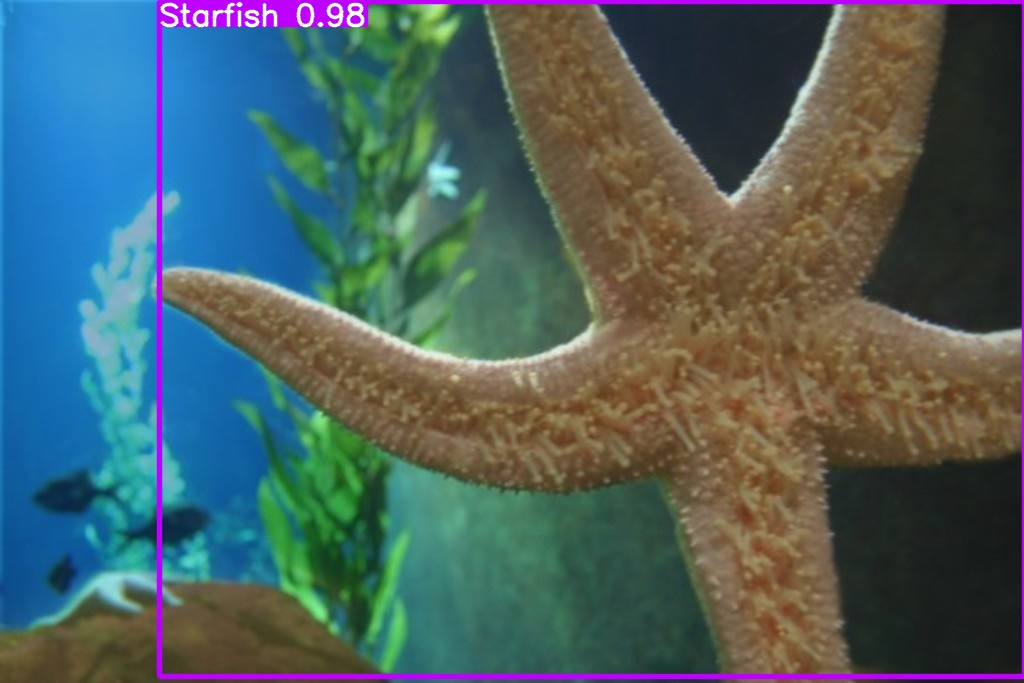

In [30]:
from IPython.display import Image, display

# Choose a random image from the validation set for inference
val_images_path = Path(OUT_DIR) / "val" / "images"
if os.path.exists(val_images_path) and os.listdir(val_images_path):
    sample_image_name = random.choice(os.listdir(val_images_path))
    sample_image_path = str(val_images_path / sample_image_name)

    print(f"Running inference on: {sample_image_path}")

    # Run inference
    results = model(sample_image_path)

    # Save the results with bounding boxes drawn
    results[0].save(filename=f"prediction_{sample_image_name}")

    # Display the result
    display(Image(filename=f"prediction_{sample_image_name}"))
else:
    print("No validation images found to run inference.")

In [31]:
metrics = model.val(
    data=str(Path(OUT_DIR) / "data.yaml"),
    imgsz=416
)

print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.102 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1403.2±639.6 MB/s, size: 351.8 KB)
val: Scanning /content/animal_yolo/val/labels.cache... 6505 images, 361 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 6505/6505 974.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 407/407 6.4it/s 1:03
                   all       6505       7175      0.495      0.511      0.496      0.419
                  Bear         39         42      0.334      0.381      0.316      0.289
                  Bull         73         91      0.406      0.209       0.29      0.251
             Butterfly        170        185      0.746      0.784      0.787       0.62
                 Camel         27         38      0.197     0.0972      0.111     0.0932
                Canary         16         18      0.231      0.667       0.39      0.338
           Caterpillar      

## 12. Locate Trained Model Weights

The trained model weights, including the best performing model, are saved within the run directory created by Ultralytics YOLO. By default, the best model is named `best.pt`.

In [32]:
weights_path = Path('runs/detect/train-2/weights')

if weights_path.exists():
    print(f"Trained model weights are located at: {weights_path}")
    print("Available weight files:")
    for f in os.listdir(weights_path):
        print(f"  - {f}")
else:
    print(f"Weights directory not found: {weights_path}")

Trained model weights are located at: runs/detect/train-2/weights
Available weight files:
  - best.pt
  - last.pt
